# 07 — Calculate Credit Spread Risk (CSR) delta across three classes

Calculate spread sensitivity while keeping the three CSR classes separate.

CS01 is the value change for a one-basis-point credit-spread movement. Non-securitisation, securitisation non-correlation-trading-portfolio (non-CTP), and correlation-trading-portfolio (CTP) remain separate.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260901T122303Z


This is the part of the calculation chain being handled here:

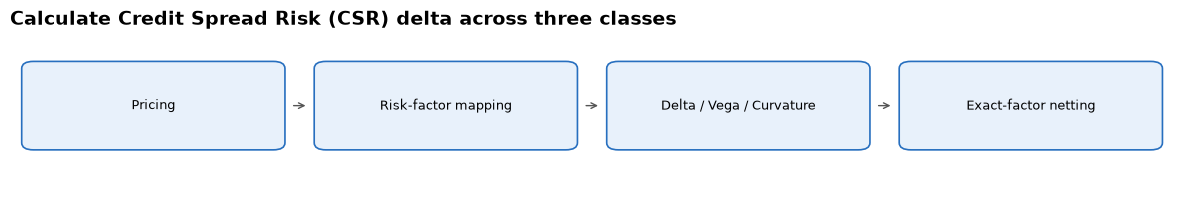

In [2]:
draw_flow(['Pricing', 'Risk-factor mapping', 'Delta / Vega / Curvature', 'Exact-factor netting'],'Calculate Credit Spread Risk (CSR) delta across three classes',wrap_after=4)

Apply a one-basis-point spread bump to one factor and numerically reprice the trade.

$$s_k=\frac{V(cs_k+0.0001)-V(cs_k)}{0.0001}$$

In [3]:
from frtb_engine.parameters import risk_weight
delta=pd.read_csv(RUN/'03_delta_trade_level.csv')
view=delta[delta.risk_class.str.startswith('CSR')].copy()
view['value_change_for_bump_inr']=view.shocked_value_inr-view.base_value_inr
view['bump_unit']=np.where(view.relative,'1% relative move','1 basis point')
view['applicable_risk_weight']=view.apply(lambda row:risk_weight(row.to_dict(),'DELTA'),axis=1)
view['tenor_display']=view.apply(
    lambda row:f"{row.tenor:g} years" if pd.notna(row.tenor)
    else 'Not applicable for this risk factor',axis=1)
columns=['trade_id','instrument_type','currency','risk_class','bucket','risk_factor_id','tenor_display',
         'bump_unit','applicable_risk_weight','base_value_inr','shocked_value_inr','value_change_for_bump_inr','raw_sensitivity']
shown=crore_table(view[columns],['base_value_inr','shocked_value_inr','value_change_for_bump_inr','raw_sensitivity'])
display(percent_columns(shown,['applicable_risk_weight']).head(25))
print('The risk weight is shown for reference. Formal weighting happens after exact-factor netting in Notebook 18.')
example=view.iloc[0]
print(f"Worked trade: {example.trade_id} | factor: {example.risk_factor_id}")
print(f"Base value: INR {example.base_value_inr/INR_CRORE:,.4f} crore")
print(f"Shocked value: INR {example.shocked_value_inr/INR_CRORE:,.4f} crore")
print(f"Value change for bump: INR {example.value_change_for_bump_inr:,.2f}")
print(f"Sensitivity = value change / bump = INR {example.raw_sensitivity:,.2f} per unit change")

,trade_id,instrument_type,currency,risk_class,bucket,risk_factor_id,tenor_display,bump_unit,Applicable Risk Weight (%),Base Value (INR crore),Shocked Value (INR crore),Value Change For Bump (INR crore),Raw Sensitivity (INR crore per unit change)
21,C01,CORPORATE_BOND,INR,CSR_NON_SECURITISATION,3,AXIS_BANK_5.0Y,5 years,1 basis point,5.0000,9.7563,9.7520,-0.0042,-42.3354
24,C02,CORPORATE_BOND,USD,CSR_NON_SECURITISATION,4,US_INDUSTRIAL_5.0Y,5 years,1 basis point,3.0000,12.4621,12.4576,-0.0045,-44.6603
25,C02,CORPORATE_BOND,USD,CSR_NON_SECURITISATION,4,US_INDUSTRIAL_10.0Y,10 years,1 basis point,3.0000,12.4621,12.4591,-0.0030,-29.7755
28,C03,CORPORATE_BOND,EUR,CSR_NON_SECURITISATION,6,EU_TECH_3.0Y,3 years,1 basis point,2.0000,11.2113,11.2080,-0.0032,-32.2617
32,C04,CORPORATE_BOND,INR,CSR_NON_SECURITISATION,12,INDIA_METALS_3.0Y,3 years,1 basis point,7.0000,6.7413,6.7402,-0.0012,-11.7923
33,C04,CORPORATE_BOND,INR,CSR_NON_SECURITISATION,12,INDIA_METALS_5.0Y,5 years,1 basis point,7.0000,6.7413,6.7402,-0.0012,-11.7923
35,C05,CDS,INR,CSR_NON_SECURITISATION,3,AXIS_BANK_5.0Y,5 years,1 basis point,5.0000,-0.0203,-0.0183,0.0020,20.4031
37,C06,CDS,USD,CSR_NON_SECURITISATION,5,US_RETAIL_5.0Y,5 years,1 basis point,3.0000,-0.0568,-0.0596,-0.0028,-28.0815
40,C07,CREDIT_OPTION,USD,CSR_NON_SECURITISATION,4,US_INDUSTRIAL_5.0Y,5 years,1 basis point,3.0000,0.0830,0.0835,0.0005,4.8557
44,C08,CALLABLE_BOND,EUR,CSR_NON_SECURITISATION,7,EU_UTILITY_5.0Y,5 years,1 basis point,1.5000,8.1260,8.1247,-0.0012,-12.3686


The risk weight is shown for reference. Formal weighting happens after exact-factor netting in Notebook 18.
Worked trade: C01 | factor: AXIS_BANK_5.0Y
Base value: INR 9.7563 crore
Shocked value: INR 9.7520 crore
Value change for bump: INR -42,335.41
Sensitivity = value change / bump = INR -423,354,121.46 per unit change


The visual below uses the calculated rows shown above.

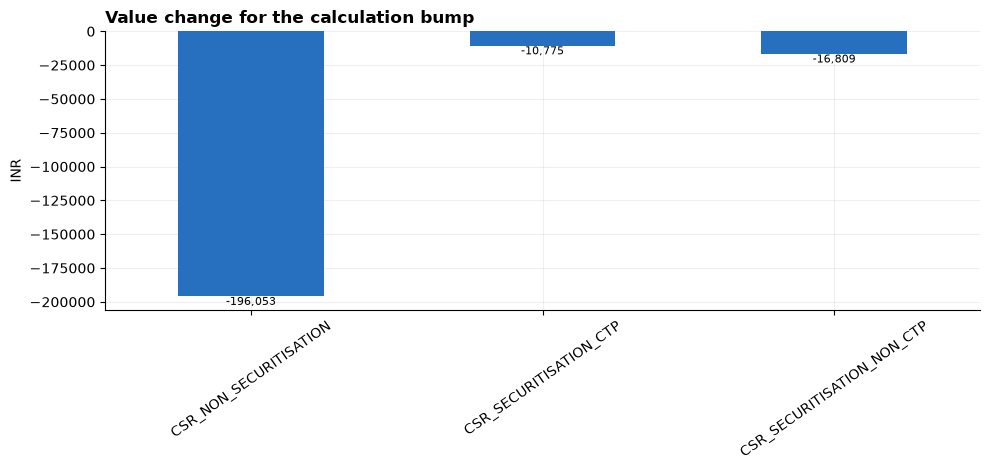

In [4]:
bar_inr(view.groupby('risk_class')['value_change_for_bump_inr'].sum(),'Value change for the calculation bump')

The identical bump concept produces three distinct regulatory CSR portfolios.